In [1]:
import torch
from tianshou.data import Collector, VectorReplayBuffer
from tianshou.env import DummyVectorEnv
from tianshou.policy import DQNPolicy
from tianshou.trainer import OffpolicyTrainer
from dengue_envs.envs.dengue_diagnostics import DengueDiagnosticsEnv
from dengue_wrapper import DengueWrapper, CaseByCaseWrapper
from fcn_network import DengueNet

C:\Users\segun\Documents\GitHub\Dengue_Diagnostics\.venv\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


In [2]:
print(f"CUDA Available: {torch.cuda.is_available()}")

CUDA Available: True


In [3]:
DEVICE = "cpu"
LR = 1e-4
GAMMA = 0.99
BUFFER_SIZE = 1
BATCH_SIZE = 64
N_STEP = 3
TARGET_UPDATE_FREQ = 500
EPS_TRAIN_START = 1.0
EPS_TRAIN_FINAL = 0.05
EPS_TRAIN_DECAY = 10
EPS_TEST = 0.01

NUM_ENVS = 4
NUM_TEST_ENVS = 4
EPOCH = 1
STEP_PER_EPOCH = 20
STEP_PER_COLLECT = 10
UPDATE_PER_STEP = 0.1

In [4]:
def make_env():
    """Função factory para criar o ambiente com wrappers."""
    env = DengueDiagnosticsEnv(epilength=60, size=400)
    env = DengueWrapper(env)
    env = CaseByCaseWrapper(env)
    return env

In [5]:
print(f"VERIFICAÇÃO: O BUFFER_SIZE é {BUFFER_SIZE}")

VERIFICAÇÃO: O BUFFER_SIZE é 1


Iniciando treinamento na cpu...


MemoryError: Unable to allocate 95.4 GiB for an array with shape (40000, 4, 400, 400) and data type float32

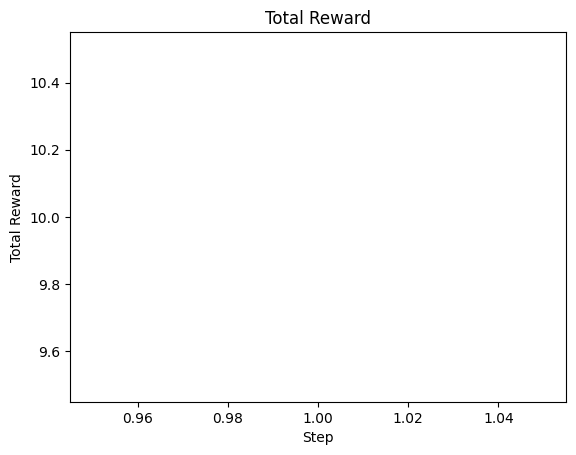

In [6]:
if True:
    train_envs = DummyVectorEnv([make_env for _ in range(NUM_ENVS)])
    test_envs = DummyVectorEnv([make_env for _ in range(NUM_TEST_ENVS)])

    env = make_env()
    map_shape = env.observation_space.spaces["map"].shape
    action_shape = env.action_space.n

    net = DengueNet(map_shape, action_shape, device=DEVICE).to(DEVICE)
    optim = torch.optim.Adam(net.parameters(), lr=LR)

    policy = DQNPolicy(
        model=net,
        optim=optim,
        discount_factor=GAMMA,
        estimation_step=N_STEP,
        target_update_freq=TARGET_UPDATE_FREQ,
        action_space=env.action_space
    )

    buffer = VectorReplayBuffer(
        total_size=BUFFER_SIZE,
        buffer_num=NUM_ENVS,
        ignore_obs_next=True
    )

    train_collector = Collector(
        policy, train_envs, buffer, exploration_noise=True
    )
    test_collector = Collector(policy, test_envs)


    def train_fn(epoch, env_step):
        if env_step <= EPS_TRAIN_DECAY:
            eps = EPS_TRAIN_START - env_step / EPS_TRAIN_DECAY * \
                  (EPS_TRAIN_START - EPS_TRAIN_FINAL)
        else:
            eps = EPS_TRAIN_FINAL
        policy.set_eps(eps)


    def test_fn(epoch, env_step):
        policy.set_eps(EPS_TEST)

    trainer = OffpolicyTrainer(
        policy=policy,
        train_collector=train_collector,
        test_collector=test_collector,
        max_epoch=EPOCH,
        step_per_epoch=STEP_PER_EPOCH,
        step_per_collect=STEP_PER_COLLECT,
        update_per_step=UPDATE_PER_STEP,
        episode_per_test=NUM_TEST_ENVS,
        batch_size=BATCH_SIZE,
        train_fn=train_fn,
        test_fn=test_fn,
        stop_fn=lambda mean_rewards: mean_rewards >= 20
    )

    print(f"Iniciando treinamento na {DEVICE}...")
    result = trainer.run()
    print("\n--- Resultado do Treinamento ---")
    print(result)

    torch.save(policy.state_dict(), "dqn_dengue_policy2.pth")
    print("Política salva em dqn_dengue_policy.pth")